# HyperGrid Rewards: Visualizing Modes on a 3D Grid (D=2, H=256)

This notebook visualizes several `GridReward` definitions from `gfn.gym.hypergrid` on a 3D surface over the 2D grid with height H=256. For each reward schema, we:

- define the mathematical form of the reward and the resulting mode set,
- compute the reward over the full grid \(X = \{0,\dots,H-1\}^2\),
- render a 3D surface of the reward landscape, and
- overlay markers for states classified as "modes" using the environment's mode threshold.

For each environment we also report:
- the total number of distinct modes (`env.n_modes`), and
- the fraction of grid states that are modes.

We keep \(H=256\) across all rewards to allow apples-to-apples comparisons. If a preset is too sparse or unreachable at this resolution, we tweak its parameters slightly to ensure that modes are visible.

In [1]:
import itertools
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused (needed for 3D)
from gfn.gym.hypergrid import HyperGrid, get_reward_presets

plt.style.use("seaborn-v0_8")

D = 2
H = 64  # common height for all plots


def build_env(reward_name: str, kwargs: dict, validate_modes: bool = True, ndim: int | None = None):
    nd = D if ndim is None else int(ndim)
    return HyperGrid(
        ndim=nd,
        height=H,
        reward_fn_str=reward_name,
        reward_fn_kwargs=kwargs,
        validate_modes=validate_modes,
        store_all_states=False,
    )


def grid_points_2d_slice(H: int, ndim: int, fixed: list[int] | None = None):
    xs = torch.arange(H)
    base = torch.cartesian_prod(xs, xs)  # (H*H, 2)
    if ndim <= 2:
        return base
    if fixed is None:
        fixed = [0] * (ndim - 2)
    assert len(fixed) == (ndim - 2)
    tail = torch.tensor(fixed, dtype=torch.long).unsqueeze(0).expand(base.shape[0], -1)
    return torch.cat([base, tail], dim=1)


def sample_points_nd(H: int, ndim: int, num_samples: int) -> torch.Tensor:
    # Uniform random sample of integer grid points in [0, H-1]^ndim
    return torch.randint(0, H, (num_samples, ndim), dtype=torch.long)


def _normalize01(x: torch.Tensor) -> torch.Tensor:
    x = x.to(dtype=torch.get_default_dtype())
    xmin = float(x.min().item())
    xmax = float(x.max().item())
    if xmax <= xmin + 1e-12:
        return torch.zeros_like(x, dtype=torch.get_default_dtype())
    return (x - xmin) / (xmax - xmin)


def plot_reward_3d(ax, title, rewards, modes_mask, cmap_name: str = "Blues", vmin: float | None = None, vmax: float | None = None, H: int | None = None):

    # Determine grid height for reshaping and axes
    HH = int(H) if H is not None else int(round(float(rewards.numel()) ** 0.5))

    # rewards shape: (HH*HH,)
    Z_t = rewards.view(HH, HH).to(dtype=torch.get_default_dtype())
    Z = Z_t.cpu().numpy()

    # Auto-scale if vmin/vmax not provided (previous behavior)
    if vmin is None or vmax is None:
        flat = Z_t.flatten()
        nz = flat[flat > 0]
        if nz.numel() >= 10:
            vmin_auto = float(torch.quantile(nz, 0.05).item())
            vmax_auto = float(torch.quantile(nz, 0.995).item())
            if vmax_auto <= vmin_auto + 1e-12:
                vmin_auto = float(nz.min().item())
                vmax_auto = float(nz.max().item())
        else:
            vmin_auto = float(flat.min().item())
            vmax_auto = float(flat.max().item())
        if vmin is None:
            vmin = vmin_auto
        if vmax is None:
            vmax = vmax_auto

    norm = Normalize(vmin=vmin, vmax=vmax)

    X, Y = np.meshgrid(np.arange(HH), np.arange(HH))
    ax.plot_surface(X, Y, Z, cmap=plt.get_cmap(cmap_name), norm=norm, linewidth=0, antialiased=True, alpha=0.9)
    # Overlay modes as red points slightly above surface
    mm = modes_mask.view(HH, HH).cpu().numpy()
    yy, xx = np.where(mm)
    if len(xx) > 0:
        ax.scatter(xx, yy, Z[yy, xx] + 1e-6, s=4, c="red", marker="o", label="modes", depthshade=False)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("reward")
    # Put a compact legend if any modes
    if len(xx) > 0:
        ax.legend(loc="upper right", fontsize=8)


def plot_pointcloud_3d(
    ax,
    title: str,
    pts: torch.Tensor,
    rewards: torch.Tensor,
    cmap_name: str = "viridis",
    min_quantile: float = 0.02,
    max_quantile: float = 0.995,
    gamma: float = 0.5,
    zero_epsilon: float = 1e-12,
    min_nonzero_alpha: float = 0.01,
    min_nonzero_size: float = 12.0,
):
    # pts: (N,3) long, rewards: (N,)
    vals_t = rewards.to(dtype=torch.get_default_dtype()).clamp_min(0)

    # Quantile-based compression over non-zero rewards so low-but-nonzero are visible
    nz_mask_t = vals_t > zero_epsilon
    nz = vals_t[nz_mask_t]
    if nz.numel() >= 5:
        vmin = float(torch.quantile(nz, min_quantile).item())
        vmax = float(torch.quantile(nz, max_quantile).item())
    else:
        vmin = float(vals_t.min().item())
        vmax = float(vals_t.max().item())
    if not (vmax > vmin):
        vmax = vmin + 1e-6

    vals = ((vals_t - vmin) / (vmax - vmin)).clamp(0.0, 1.0)
    # Gamma to brighten low values while keeping highs distinct
    vals_np = torch.pow(vals, gamma).cpu().numpy()

    # Sizes and colors
    s_min, s_max = 6.0, 26.0
    sizes = s_min + (s_max - s_min) * vals_np
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(vals_np)
    alpha_min, alpha_max = 0.01, 0.5
    alphas = alpha_min + (alpha_max - alpha_min) * vals_np

    # Make exact zeros transparent
    zeros_mask = (vals_t <= zero_epsilon).cpu().numpy()
    alphas[zeros_mask] = 0.0

    # Ensure nonzero points have minimum visibility (handles discrete rewards like MultiplicativeCoprime)
    nz_mask = nz_mask_t.cpu().numpy()
    alphas[nz_mask] = np.maximum(alphas[nz_mask], float(min_nonzero_alpha))
    sizes[nz_mask] = np.maximum(sizes[nz_mask], float(min_nonzero_size))

    colors[:, 3] = alphas

    x = pts[:, 0].cpu().numpy()
    y = pts[:, 1].cpu().numpy()
    z = pts[:, 2].cpu().numpy()
    ax.scatter(x, y, z, c=colors, s=sizes, marker="o", depthshade=True)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")


def plot_pointcloud_rungs_3d(
    ax,
    title: str,
    pts: torch.Tensor,
    rung_ids: torch.Tensor,
    rewards: torch.Tensor | None = None,
    tab_cmap = plt.get_cmap("tab10"),
    non_rung_rgba = (0.7, 0.7, 0.7, 0.15),
    min_quantile: float = 0.02,
    max_quantile: float = 0.995,
    gamma: float = 0.5,
    zero_epsilon: float = 1e-12,
    min_nonzero_alpha: float = 0.01,
    min_nonzero_size: float = 12.0,
):
    # Determine alpha/size from rewards if provided; otherwise use defaults
    if rewards is not None:
        vals_t = rewards.to(dtype=torch.get_default_dtype()).clamp_min(0)
        nz_mask_t = vals_t > zero_epsilon
        nz = vals_t[nz_mask_t]
        if nz.numel() >= 5:
            vmin = float(torch.quantile(nz, min_quantile).item())
            vmax = float(torch.quantile(nz, max_quantile).item())
        else:
            vmin = float(vals_t.min().item())
            vmax = float(vals_t.max().item())
        if not (vmax > vmin):
            vmax = vmin + 1e-6
        vals = ((vals_t - vmin) / (vmax - vmin)).clamp(0.0, 1.0)
        vals_np = torch.pow(vals, gamma).cpu().numpy()
        s_min, s_max = 6.0, 26.0
        sizes = s_min + (s_max - s_min) * vals_np
        alpha_min, alpha_max = 0.01, 0.5
        alphas = alpha_min + (alpha_max - alpha_min) * vals_np
        zeros_mask = (vals_t <= zero_epsilon).cpu().numpy()
        alphas[zeros_mask] = 0.0
        nz_mask = nz_mask_t.cpu().numpy()
        alphas[nz_mask] = np.maximum(alphas[nz_mask], float(min_nonzero_alpha))
        sizes[nz_mask] = np.maximum(sizes[nz_mask], float(min_nonzero_size))
    else:
        N = pts.shape[0]
        sizes = np.full(N, 10.0, dtype=np.float32)
        alphas = np.full(N, 0.5, dtype=np.float32)

    # Build colors by rung id while preserving computed alpha
    N = pts.shape[0]
    colors = np.zeros((N, 4), dtype=np.float32)
    # Initialize as non-rung
    colors[:] = non_rung_rgba
    for t in range(min(10, 1 + int(rung_ids.max().item()) if rung_ids.numel() > 0 else 0)):
        mask = (rung_ids == t).cpu().numpy()
        if np.any(mask):
            rgba = np.array(tab_cmap(t % 10), dtype=np.float32)
            colors[mask, :3] = rgba[:3]
    # Apply alpha from alphas array for all points
    colors[:, 3] = np.maximum(colors[:, 3], alphas.astype(np.float32))

    x = pts[:, 0].cpu().numpy()
    y = pts[:, 1].cpu().numpy()
    z = pts[:, 2].cpu().numpy()
    ax.scatter(x, y, z, c=colors, s=sizes, marker="o", depthshade=True)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")


def compute_rewards_and_modes(env: HyperGrid, pts: torch.Tensor):
    rewards = env.reward(env.States(pts))  # shape (N,)
    mask = env.mode_mask(env.States(pts))  # shape (N,)
    return rewards, mask


def summarize_modes(env: HyperGrid, mask: torch.Tensor, label: str = ""):
    prefix = (label + ": ") if label else ""
    n_modes_distinct = env.n_modes
    frac_modes = float(mask.float().mean().item())
    print(f"{prefix}n_modes (distinct): {n_modes_distinct}")
    print(f"{prefix}% of plotted grid states that are modes: {100.0 * frac_modes:.4f}%")



/Users/jdv/miniconda3/envs/gfn-communities/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_19101/4236655083.py:166: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab_cmap = cm.get_cmap("tab10"),


## Original Reward

The Original reward (Bengio et al., 2021) is
\[
R(x) = R_0 \; + \; R_1 \; \prod_{i=1}^D \mathbf{1}[0.25 < a_i(x) \le 0.5] \; + \; R_2 \; \prod_{i=1}^D \mathbf{1}[0.3 < a_i(x) < 0.4],
\]
where
\[ a_i(x) = \left| \frac{x_i}{H-1} - \tfrac{1}{2} \right|. \]
Modes are the thin band where both products equal 1 (outer ring and inner band).


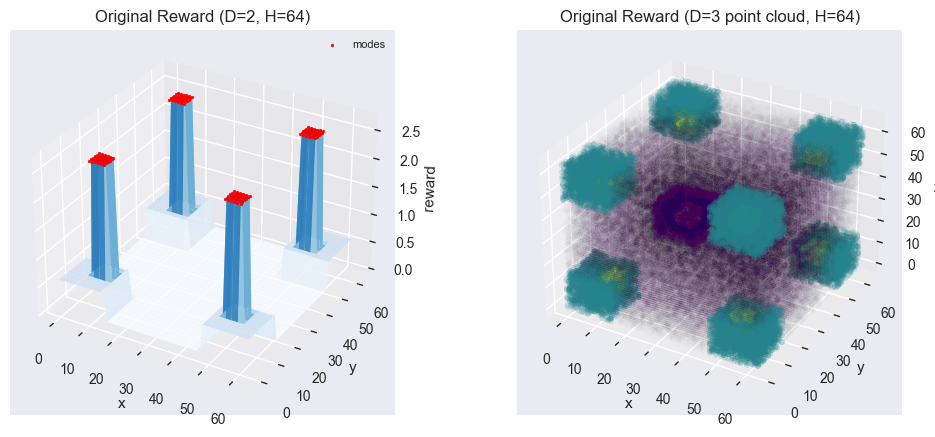

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 3.5156%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 0.6735%


In [2]:
orig_kwargs = dict(R0=0.1, R1=0.5, R2=2.0)

# D=2
orig_env2 = build_env("original", orig_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
orig_rewards2, orig_modes2 = compute_rewards_and_modes(orig_env2, pts2)

# D=3 (plot a 2D slice at z=0)
orig_env3 = build_env("original", orig_kwargs, validate_modes=False, ndim=3)
pts3 = grid_points_2d_slice(H, 3, fixed=[0])
orig_rewards3, orig_modes3 = compute_rewards_and_modes(orig_env3, pts3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(ax1, "Original Reward (D=2, H={})".format(H), orig_rewards2, orig_modes2, H=H)
ax2 = fig.add_subplot(122, projection="3d")
# D=3 point cloud: sample points and size/alpha by reward
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(orig_env3, pts3_pc)
plot_pointcloud_3d(ax2, "Original Reward (D=3 point cloud, H={})".format(H), pts3_pc, rewards3_pc)
plt.show()

summarize_modes(orig_env2, orig_modes2, label="D=2")
# For point cloud, report fraction of sampled points that are modes
mask3_pc = orig_env3.mode_mask(orig_env3.States(pts3_pc))
summarize_modes(orig_env3, mask3_pc, label="D=3 (point cloud)")

## Deceptive Reward

The Deceptive reward is
\[
R(x) = (R_0 + R_1) \; - \; R_1 \; \prod_{i=1}^D \mathbf{1}[0.1 < a_i(x)] \; + \; R_2 \; \prod_{i=1}^D \mathbf{1}[0.3 < a_i(x) < 0.4].
\]
Compared to Original, the outer region cancels \(R_1\), the center keeps \(R_1\), and the band still adds \(R_2\). Modes lie on the thin band.


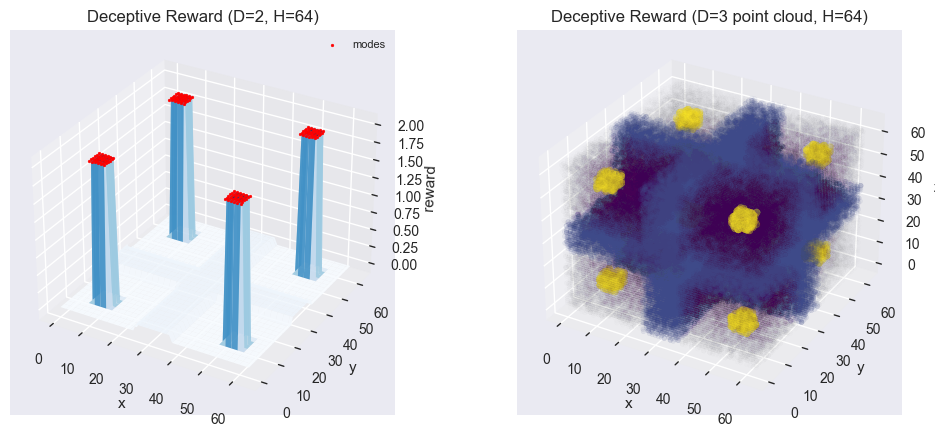

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 3.5156%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 0.6610%


In [3]:
dec_kwargs = dict(R0=1e-5, R1=0.1, R2=2.0)

# D=2
dec_env2 = build_env("deceptive", dec_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
dec_rewards2, dec_modes2 = compute_rewards_and_modes(dec_env2, pts2)

# D=3 slice
dec_env3 = build_env("deceptive", dec_kwargs, validate_modes=False, ndim=3)
pts3 = grid_points_2d_slice(H, 3, fixed=[0])
dec_rewards3, dec_modes3 = compute_rewards_and_modes(dec_env3, pts3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(ax1, "Deceptive Reward (D=2, H={})".format(H), dec_rewards2, dec_modes2, H=H)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(dec_env3, pts3_pc)
plot_pointcloud_3d(ax2, "Deceptive Reward (D=3 point cloud, H={})".format(H), pts3_pc, rewards3_pc)
plt.show()

summarize_modes(dec_env2, dec_modes2, label="D=2")
mask3_pc = dec_env3.mode_mask(dec_env3.States(pts3_pc))
summarize_modes(dec_env3, mask3_pc, label="D=3 (point cloud)")

## Cosine Reward

Let \(a_i(x) = |x_i/(H-1) - 1/2|\). Define
\[
R(x) = R_0 + R_1 \prod_{i=1}^D \big( (\cos(50\, a_i(x)) + 1) \cdot \tfrac{1}{\sqrt{2\pi}} e^{-\tfrac{1}{2} (5\,a_i(x))^2} \big).
\]
Modes correspond to the product being near its peak; the mode threshold uses a \(\gamma\)-scaled per-dimension peak.


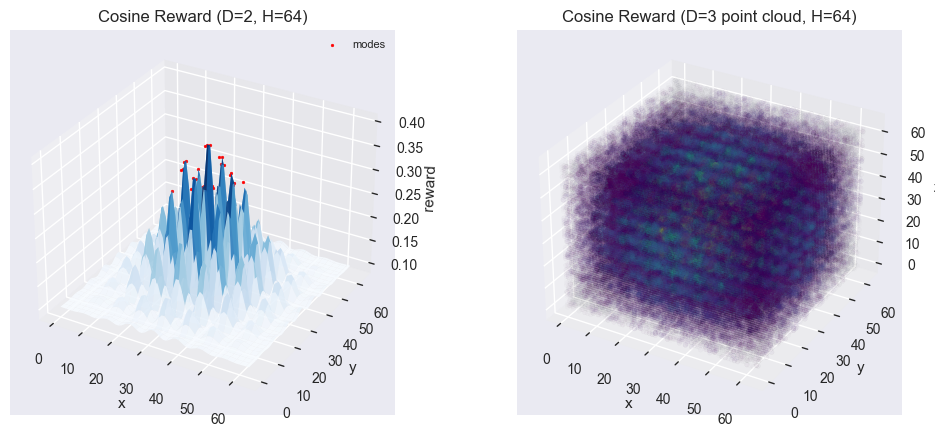

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 0.7812%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 0.0975%


In [4]:
cos_kwargs = dict(R0=0.1, R1=0.5, mode_gamma=0.8)

# D=2
cos_env2 = build_env("cosine", cos_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
cos_rewards2, cos_modes2 = compute_rewards_and_modes(cos_env2, pts2)

# D=3 slice
cos_env3 = build_env("cosine", cos_kwargs, validate_modes=False, ndim=3)
pts3 = grid_points_2d_slice(H, 3, fixed=[0])
cos_rewards3, cos_modes3 = compute_rewards_and_modes(cos_env3, pts3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(ax1, "Cosine Reward (D=2, H={})".format(H), cos_rewards2, cos_modes2, H=H)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(cos_env3, pts3_pc)
plot_pointcloud_3d(
    ax2,
    "Cosine Reward (D=3 point cloud, H={})".format(H),
    pts3_pc,
    rewards3_pc,
)
plt.show()

summarize_modes(cos_env2, cos_modes2, label="D=2")
mask3_pc = cos_env3.mode_mask(cos_env3.States(pts3_pc))
summarize_modes(cos_env3, mask3_pc, label="D=3 (point cloud)")

## Sparse Reward (GAFN paper)

Targets are constructed by taking, for each \(k \in \{0,\dots,D\}\), all distinct permutations of a vector with \(k\) ones and \(D-k\) entries equal to \(H-2\). The reward is
\[
R(x) = \sum_{t \in T} \mathbf{1}[x = t] + \varepsilon, \quad \varepsilon > 0,
\]
which yields extremely sparse spikes at known locations.


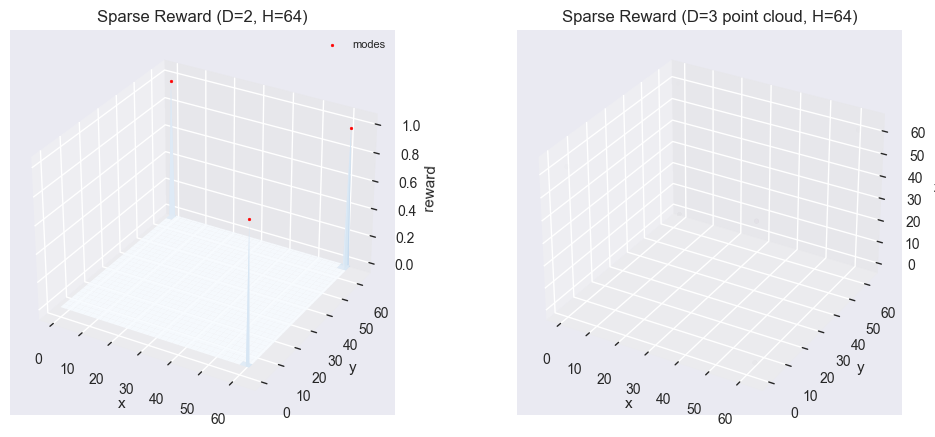

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 0.0732%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 0.0065%


In [5]:
sparse_kwargs = {}

# D=2
sparse_env2 = build_env("sparse", sparse_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
sparse_rewards2, sparse_modes2 = compute_rewards_and_modes(sparse_env2, pts2)

# D=3 slice
sparse_env3 = build_env("sparse", sparse_kwargs, validate_modes=False, ndim=3)
pts3 = grid_points_2d_slice(H, 3, fixed=[0])
sparse_rewards3, sparse_modes3 = compute_rewards_and_modes(sparse_env3, pts3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(ax1, "Sparse Reward (D=2, H={})".format(H), sparse_rewards2, sparse_modes2, H=H)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(sparse_env3, pts3_pc)
plot_pointcloud_3d(ax2, "Sparse Reward (D=3 point cloud, H={})".format(H), pts3_pc, rewards3_pc)
plt.show()

summarize_modes(sparse_env2, sparse_modes2, label="D=2")
mask3_pc = sparse_env3.mode_mask(sparse_env3.States(pts3_pc))
summarize_modes(sparse_env3, mask3_pc, label="D=3 (point cloud)")

## Bitwise/XOR Reward (compositional)

We constrain bit-planes over GF(2). For tier \(t\) with bit window \([\ell_t, h_t]\), let
\(u^{(b)} \in \{0,1\}^m\) be the bits at plane \(b\) across constrained dims; enforce
\(A_t u^{(b)} \equiv c_t \; (\text{mod } 2)\) or even parity if unspecified. Reward tiers add when all constraints up to tier-\(t\) hold.


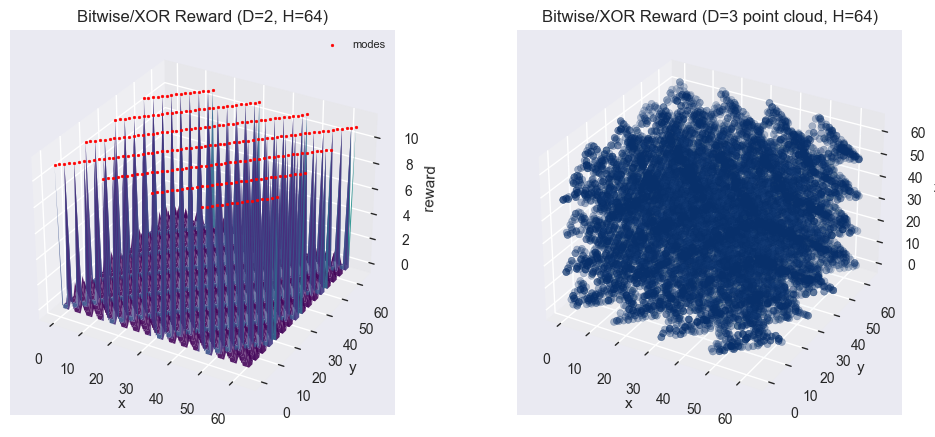

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 6.2500%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 6.2540%


In [6]:
xor_kwargs = get_reward_presets("bitwise_xor", D, H)["easy"].copy()
# Check only low bits so high bits are free -- creates a fractal block pattern
# instead of a single diagonal line. Tier 0: bits 0-1, tier 1: adds bits 2-3.
# Unchecked bits 4-7 tile the pattern 16x across the grid.
xor_kwargs.update(dict(dims_constrained=[0, 1], bits_per_tier=[(0, 1), (0, 3)], tier_weights=[1.0, 10.0]))
# Drop preset parity_checks (3 tiers) so it matches the 2-tier override above.
xor_kwargs.pop("parity_checks", None)

# D=2
xor_env2 = build_env("bitwise_xor", xor_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
xor_rewards2, xor_modes2 = compute_rewards_and_modes(xor_env2, pts2)

# D=3 slice -- constrain all 3 dims for richer cross-dimensional structure
xor_kwargs_3d = xor_kwargs.copy()
xor_kwargs_3d["dims_constrained"] = [0, 1, 2]
xor_env3 = build_env("bitwise_xor", xor_kwargs_3d, validate_modes=False, ndim=3)
pts3 = grid_points_2d_slice(H, 3, fixed=[0])
xor_rewards3, xor_modes3 = compute_rewards_and_modes(xor_env3, pts3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(
    ax1,
    "Bitwise/XOR Reward (D=2, H={})".format(H),
    xor_rewards2,
    xor_modes2,
    vmin=0,
    cmap_name="viridis",
    H=H,
)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(xor_env3, pts3_pc)
plot_pointcloud_3d(
    ax2,
    "Bitwise/XOR Reward (D=3 point cloud, H={})".format(H),
    pts3_pc,
    rewards3_pc,
    cmap_name="Blues",
)
plt.show()
summarize_modes(xor_env2, xor_modes2, label="D=2")
mask3_pc = xor_env3.mode_mask(xor_env3.States(pts3_pc))
summarize_modes(xor_env3, mask3_pc, label="D=3 (point cloud)")

## Multiplicative/Coprime Reward (compositional)

Per-dimension values must factor over a small prime set with bounded exponents (cap per tier), plus optional cross-dimension coprimality and LCM targets. Reward tiers add when constraints up to tier-\(t\) hold.


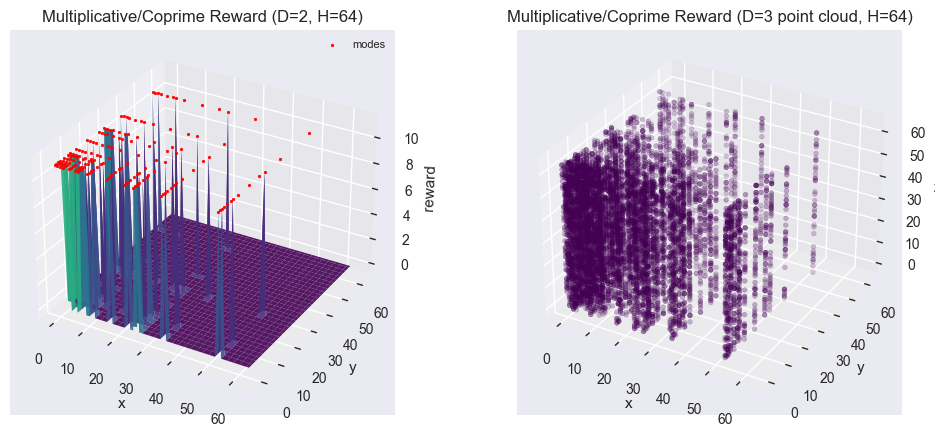

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 4.1260%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 4.1735%


In [7]:
mc_kwargs = dict(R0=0.0, tier_weights=[1.0, 10.0], primes=[2, 3], exponent_caps=[3, 3], active_dims=[0, 1])

# D=2
mc_env2 = build_env("multiplicative_coprime", mc_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
mc_rewards2, mc_modes2 = compute_rewards_and_modes(mc_env2, pts2)

# D=3 slice
mc_env3 = build_env("multiplicative_coprime", mc_kwargs, validate_modes=False, ndim=3)
pts3 = grid_points_2d_slice(H, 3, fixed=[0])
mc_rewards3, mc_modes3 = compute_rewards_and_modes(mc_env3, pts3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(
    ax1,
    "Multiplicative/Coprime Reward (D=2, H={})".format(H),
    mc_rewards2,
    mc_modes2,
    vmin=0,
    cmap_name="viridis",
    H=H,
)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(mc_env3, pts3_pc)
plot_pointcloud_3d(
    ax2,
    "Multiplicative/Coprime Reward (D=3 point cloud, H={})".format(H),
    pts3_pc,
    rewards3_pc,
    min_quantile=0.02,
    max_quantile=0.7,
    gamma=0.25,
    min_nonzero_alpha=0.4,
)
plt.show()

summarize_modes(mc_env2, mc_modes2, label="D=2")
mask3_pc = mc_env3.mode_mask(mc_env3.States(pts3_pc))
summarize_modes(mc_env3, mask3_pc, label="D=3 (point cloud)")

## Conditional Multi-Scale Reward (compositional)

Each coordinate is decomposed in base $B$ into $L = \log_B(H)$ digits:
$$s_i = d_0(i) + B \cdot d_1(i) + B^2 \cdot d_2(i) + \cdots$$

Tier $t$ (0-indexed) constrains digit $t$ via a **shifted filter** that depends on all finer-scale digits:
$$\bigl(d_t(i) + \sigma_t(i)\bigr) \bmod B < f$$
where $\sigma_t(i) = \sum_{k=0}^{t-1} a_{t,k} \cdot d_k(i) \bmod B$ with seed-derived coefficients $a_{t,k}$.

**Key properties:**
- Each tier introduces a qualitatively different constraint whose form depends on prior tiers (conditional cross-scale structure).
- Exact closed-form mode count: $\text{modes}_T = \bigl(\prod_{t=1}^T f_t\bigr)^d \cdot B^{(L-T) \cdot d}$
- Analytic partition function: $Z = R_0 \cdot H^d + \sum_t w_t \cdot \text{modes}_t$
- Seed-reproducible shift coefficients.

**Comparison with other compositional rewards:**
- *BitwiseXOR*: same parity check at every bit-plane (no cross-scale dependency).
- *MultiplicativeCoprime*: same prime-factorization check per tier (tighter caps).
- *This class*: the constraint at scale $k$ is a **function of** scales $0 \ldots k{-}1$, creating a hierarchy where learning lower-scale rules bootstraps discovery of higher-scale modes.

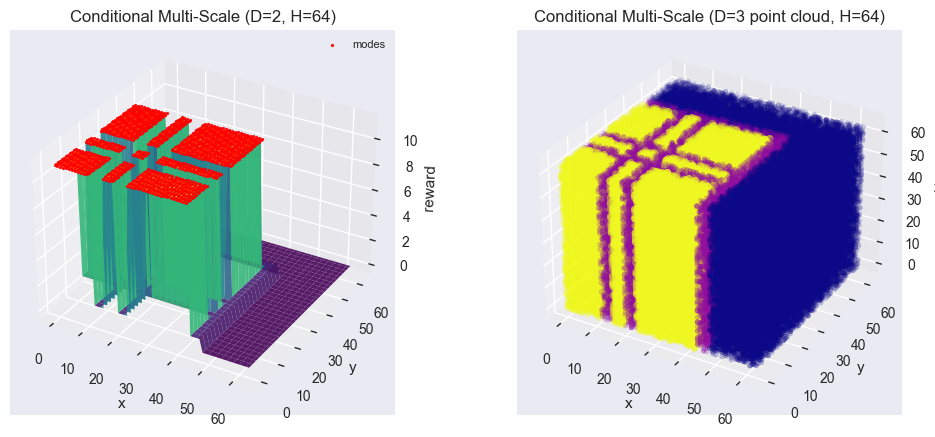

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 31.6406%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 31.5965%

Analytic mode counts:
  Tier 1: 2,304 modes
  Tier 2: 1,296 modes
  log Z = 9.6597


In [8]:
cms_kwargs = dict(
    R0=0.1,  # small base reward so full grid is visible
    tier_weights=[1.0, 10.0],  # 2 tiers (H=64, base=4 -> L=3 digits; leave 1 free)
    base=4,
    filter_width=3,  # 3/4 digit values pass -> gentler curriculum (75% per axis per tier)
    seed=42,
    active_dims=[0, 1],
)

# D=2
cms_env2 = build_env("conditional_multiscale", cms_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
cms_rewards2, cms_modes2 = compute_rewards_and_modes(cms_env2, pts2)

# D=3 slice
cms_env3 = build_env("conditional_multiscale", cms_kwargs, validate_modes=False, ndim=3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(
    ax1,
    "Conditional Multi-Scale (D=2, H={})".format(H),
    cms_rewards2,
    cms_modes2,
    vmin=0,
    cmap_name="viridis",
    H=H,
)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(cms_env3, pts3_pc)
plot_pointcloud_3d(
    ax2,
    "Conditional Multi-Scale (D=3 point cloud, H={})".format(H),
    pts3_pc,
    rewards3_pc,
    cmap_name="plasma",
    min_nonzero_alpha=0.3,
)
plt.show()

summarize_modes(cms_env2, cms_modes2, label="D=2")
mask3_pc = cms_env3.mode_mask(cms_env3.States(pts3_pc))
summarize_modes(cms_env3, mask3_pc, label="D=3 (point cloud)")

# Report analytic mode counts per tier
print("\nAnalytic mode counts:")
for t in range(len(cms_kwargs["tier_weights"])):
    print(f"  Tier {t+1}: {cms_env2.reward_fn.analytic_mode_count(tier=t+1):,} modes")
print(f"  log Z = {cms_env2.reward_fn.analytic_log_partition():.4f}")

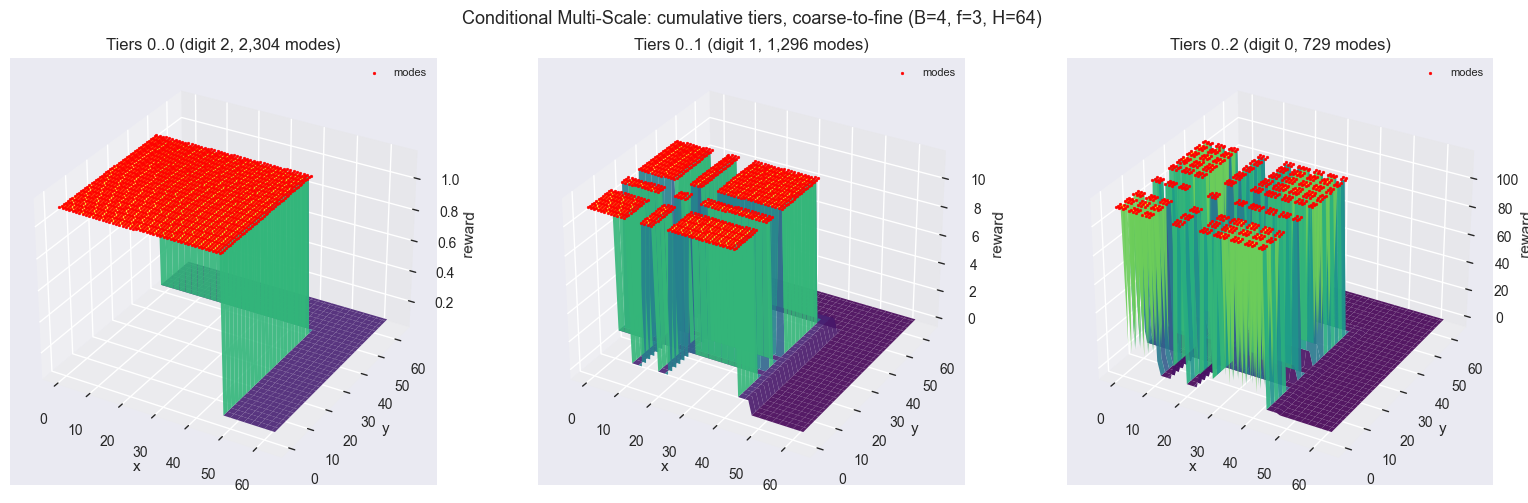

Shift coefficients (seed=42), coarse-to-fine ordering:
  Tier 0 (digit 2, MSB): no shift (base constraint)
  Tier 1 (digit 1): shift = 2*d2 mod 4
  Tier 2 (digit 0): shift = 3*d2 + 0*d1 mod 4


In [9]:
# Visualize tier-by-tier structure of ConditionalMultiScale reward
# Coarse-to-fine ordering: tier 0 constrains the MSB (coarsest digit),
# tier 1 constrains the next digit conditioned on the coarser one, etc.
# States near the origin (small coords, high digits = 0) easily pass tier 0.

def plot_cms_tiers(H: int):
    """Show the reward landscape for each tier individually."""
    base = 4
    f_width = 3  # 3/4 digit values pass -> gentler curriculum
    base_kwargs = dict(base=base, filter_width=f_width, seed=42, active_dims=[0, 1], R0=0.1)

    # Compute number of digit levels
    L = 0
    h = H
    while h > 1 and h % base == 0:
        h //= base
        L += 1
    tier_weights_all = [10.0**i for i in range(L)]

    n_tiers = min(L, 3)  # show up to 3 tiers
    fig, axes = plt.subplots(1, n_tiers, figsize=(16, 5), subplot_kw={"projection": "3d"})
    if n_tiers == 1:
        axes = [axes]
    pts2 = grid_points_2d_slice(H, 2)

    for t in range(n_tiers):
        # Build an env with only tiers up to t+1
        kw = dict(base_kwargs)
        kw["tier_weights"] = tier_weights_all[: t + 1]
        env = build_env("conditional_multiscale", kw, validate_modes=True, ndim=2)
        rewards, modes = compute_rewards_and_modes(env, pts2)
        n_modes = env.reward_fn.analytic_mode_count(tier=t + 1)
        digit_idx = L - 1 - t  # coarse-to-fine: tier t constrains digit (L-1-t)

        plot_reward_3d(
            axes[t],
            f"Tiers 0..{t} (digit {digit_idx}, {n_modes:,} modes)",
            rewards,
            modes,
            vmin=0,
            cmap_name="viridis",
            H=H,
        )

    plt.suptitle(
        f"Conditional Multi-Scale: cumulative tiers, coarse-to-fine (B={base}, f={f_width}, H={H})",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

    # Print the shift coefficients to show the conditional structure
    env_full = build_env(
        "conditional_multiscale",
        dict(base_kwargs, tier_weights=tier_weights_all[:n_tiers]),
        validate_modes=True,
        ndim=2,
    )
    print("Shift coefficients (seed=42), coarse-to-fine ordering:")
    # ConditionalMultiScaleReward stores coefficients per rule; at the default
    # n_rules=1, rule 0 holds the historical single-rule shifts.
    for t, coeffs in enumerate(env_full.reward_fn.shift_coeffs_per_rule[0]):
        digit_idx = L - 1 - t
        if not coeffs:
            print(f"  Tier {t} (digit {digit_idx}, MSB): no shift (base constraint)")
        else:
            coarser_descs = [f"{a}*d{L-1-k}" for k, a in enumerate(coeffs)]
            print(f"  Tier {t} (digit {digit_idx}): shift = {' + '.join(coarser_descs)} mod {base}")


plot_cms_tiers(H)

### Adaptive mode tier

Because tiers are cumulative (tier-$k$ modes $\subset$ tier-$(k{-}1)$ modes), the
fraction of the state space with *any* reward is $(f/B)^d$ — which ranges from
25% at $d{=}2$ to near-zero at $d{=}16$. Lower tiers act as "foothills" that guide
the GFlowNet toward harder, higher-tier modes.

The **mode tier** adapts the mode-counting threshold to dimensionality: it picks
the lowest tier whose coverage drops below a target sparsity $\tau$ (default 10%).
A mode can reasonably be a few percent of the state space — what matters is that
the *highest-reward* modes are rare, while lower tiers provide learning signal.

$$\text{mode\_tier}(\tau) = \min\bigl\{t : (f/B)^{t \cdot d} < \tau\bigr\}$$

Adaptive mode tier (B=4, f=2, H=64, tau=0.1)
   d  mode_tier   threshold      mode count    coverage
-------------------------------------------------------
   2          2          11             256    0.062500
   4          1           1       1,048,576    0.062500
   8          1           1  1,099,511,627,776    0.003906
  16          1           1  1,208,925,819,614,629,174,706,176    0.000015
  32          1           1  1,461,501,637,330,902,918,203,684,832,716,283,019,655,932,542,976    0.000000


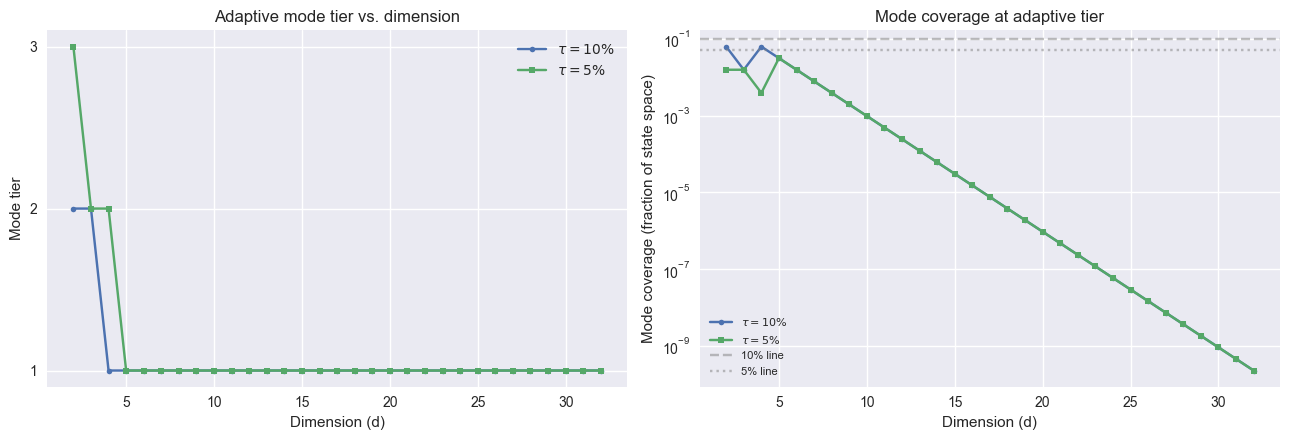

In [10]:
from gfn.gym.hypergrid import ConditionalMultiScaleReward

# --- Table: adaptive mode tier across dimensions ---
B, f = 4, 2
weights = [1.0, 10.0, 100.0]  # 3 tiers (L=3 for H=64)
tau = 0.10  # 10% target sparsity (modes can be a few % of states)

print(f"Adaptive mode tier (B={B}, f={f}, H={H}, tau={tau})")
print("   d  mode_tier   threshold      mode count    coverage")
print("-" * 55)
for d in [2, 4, 8, 16, 32]:
    r = ConditionalMultiScaleReward(
        height=H, ndim=d, tier_weights=weights, base=B, filter_width=f, seed=42,
    )
    mt = r.mode_tier(tau)
    thr = r.mode_threshold(tau)
    modes = r.analytic_mode_count(tier=mt)
    total = H**d
    cov = modes / total
    print(f"{d:4d}  {mt:9d}  {thr:10.0f}  {modes:14,}  {cov:10.6f}")

# --- Plot: how mode tier and coverage vary with dimension ---
dims = list(range(2, 33))
tiers_10pct = []
tiers_5pct = []
coverages_10pct = []
coverages_5pct = []

for d in dims:
    r = ConditionalMultiScaleReward(
        height=H, ndim=d, tier_weights=weights, base=B, filter_width=f, seed=42,
    )
    mt10 = r.mode_tier(0.10)
    mt5 = r.mode_tier(0.05)
    tiers_10pct.append(mt10)
    tiers_5pct.append(mt5)
    coverages_10pct.append((f / B) ** (mt10 * d))
    coverages_5pct.append((f / B) ** (mt5 * d))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(dims, tiers_10pct, "o-", label=r"$\tau=10\%$", markersize=4)
ax1.plot(dims, tiers_5pct, "s-", label=r"$\tau=5\%$", markersize=4)
ax1.set_xlabel("Dimension (d)")
ax1.set_ylabel("Mode tier")
ax1.set_title("Adaptive mode tier vs. dimension")
ax1.legend()
ax1.set_yticks(range(1, max(max(tiers_10pct), max(tiers_5pct)) + 1))

ax2.semilogy(dims, coverages_10pct, "o-", label=r"$\tau=10\%$", markersize=4)
ax2.semilogy(dims, coverages_5pct, "s-", label=r"$\tau=5\%$", markersize=4)
ax2.axhline(0.10, color="gray", linestyle="--", alpha=0.5, label="10% line")
ax2.axhline(0.05, color="gray", linestyle=":", alpha=0.5, label="5% line")
ax2.set_xlabel("Dimension (d)")
ax2.set_ylabel("Mode coverage (fraction of state space)")
ax2.set_title("Mode coverage at adaptive tier")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Visual demonstration of the functioning of the `verify_modes` flag.

The `verify_modes` flag is used to ensure that high reward regions are defined for your given setting. Particularly for small hypergrids, this may not be true. Below is a demonstration of what the reward landscapes look like for environments with D=2 and H=range(2,...,22) with the original reward.

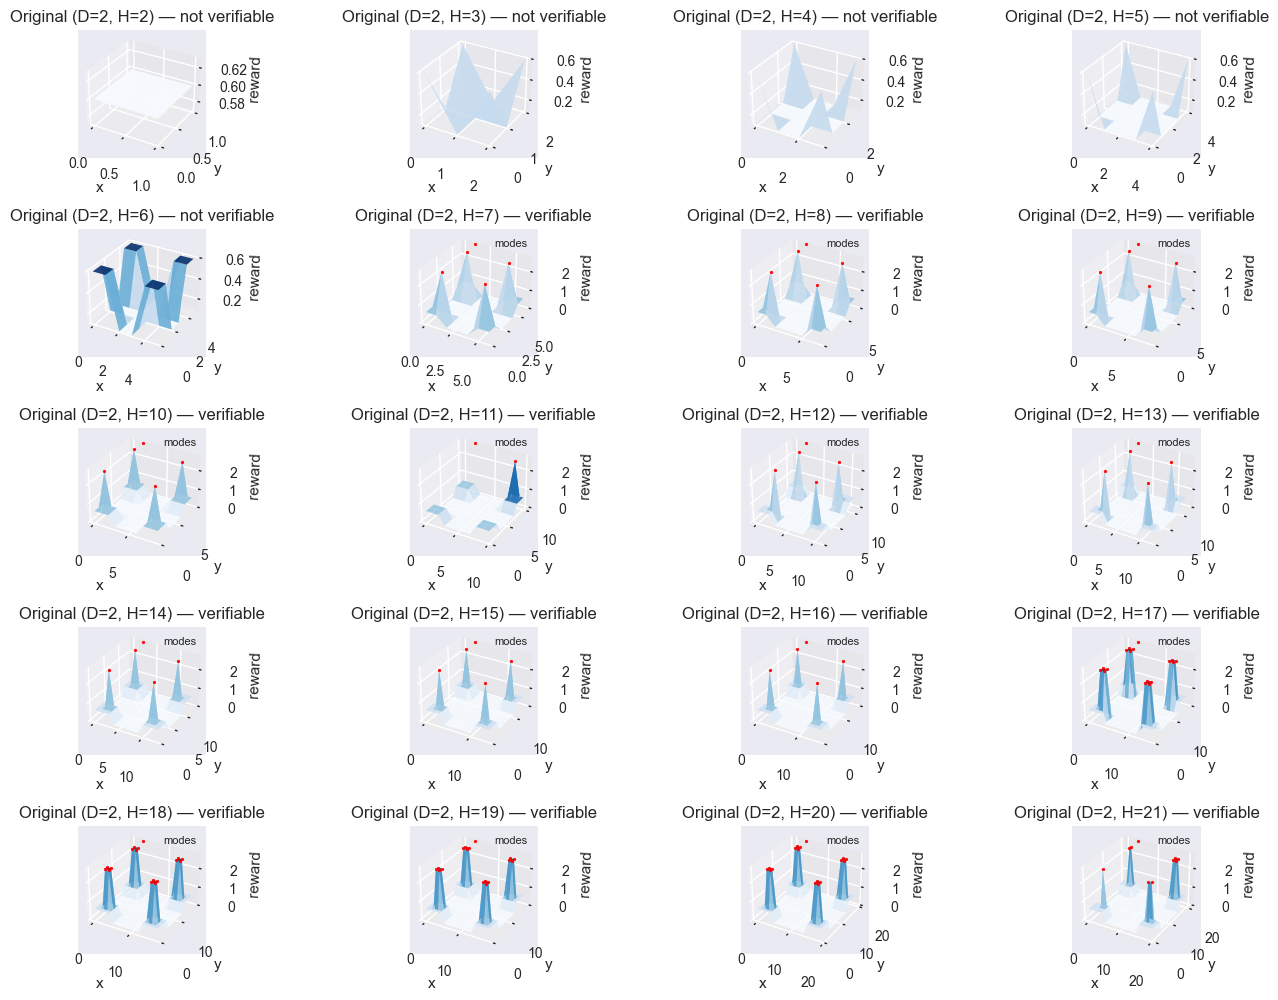

In [11]:
# Grid of Original reward landscapes for D=2 across H=2..21 with verifiability labels

fig = plt.figure(figsize=(16, 12))
Hs = list(range(2, 22))
rows, cols = 5, 4

for idx, HH in enumerate(Hs):
    ax = fig.add_subplot(rows, cols, idx + 1, projection="3d")
    reward_kwargs = dict(R0=0.1, R1=0.5, R2=2.0)

    # Check verifiability by attempting validation-enabled construction
    try:
        _ = HyperGrid(ndim=2, height=HH, reward_fn_str="original", reward_fn_kwargs=reward_kwargs, validate_modes=True, store_all_states=False)
        verifiable = True
    except Exception:
        verifiable = False

    # Build plotting env without validation to ensure the grid renders regardless
    env = HyperGrid(ndim=2, height=HH, reward_fn_str="original", reward_fn_kwargs=reward_kwargs, validate_modes=False, store_all_states=False)
    pts = grid_points_2d_slice(HH, 2)
    rewards, modes_mask = compute_rewards_and_modes(env, pts)
    tag = "verifiable" if verifiable else "not verifiable"
    plot_reward_3d(ax, f"Original (D=2, H={HH}) — {tag}", rewards, modes_mask, H=HH)

# Add more spacing to avoid label/title overlap
plt.subplots_adjust(wspace=0.35, hspace=0.55)
plt.show()

# K-rule sparser rewards (trunk + per-rule heads)

The three compositional rewards above (`bitwise_xor`, `multiplicative_coprime`,
`conditional_multiscale`) all support a **K-rule trunk + heads** extension that:

1. Sparsifies the mode set (per-rule head adds a constraint).
2. Partitions modes across `n_rules` deterministic buckets via a state-derived
   selector. Each rule's modes are *disjoint* — a state belongs to exactly one rule.
3. Total mode count is invariant in K (the same canonical mode set is partitioned,
   not duplicated). This decouples "specialization opportunity" from "exploration
   difficulty" in (K_agents, K_rules) sweeps.

At D=2 we can only show small K (the selector's pattern budget is `f^d_active`
for multiscale, `2^k_select ≤ 2^(M·B)` for bitxor, `top_cap^n_primes` for
coprime — all small at D=2). The plots below pair K=1 (single rule, baseline
sparser-than-medium density) with K=4 (selector partitions modes into 4
disjoint regions, color-coded).

In each plot:
- The 3D surface shows the reward landscape (height = reward, color = magnitude).
- **Mode states** are overlaid as colored markers; at K>1 the marker color
  encodes which rule the mode belongs to.

In [12]:
def _selector_for_state(env, x: torch.Tensor) -> torch.Tensor:
    """Compute the selector (rule index) for a batch of states (..., ndim).

    Dispatches per reward class.
    """
    rf = env.reward_fn
    from gfn.gym.hypergrid import (
        BitwiseXORReward,
        ConditionalMultiScaleReward,
        MultiplicativeCoprimeReward,
    )
    if isinstance(rf, ConditionalMultiScaleReward):
        digits_top = (x // (rf.base ** (rf.num_levels - 1))) % rf.base
        active = torch.tensor(rf.active_dims, device=x.device)
        return rf._selector(digits_top.index_select(-1, active).long())
    if isinstance(rf, BitwiseXORReward):
        x_constrained = x.index_select(-1, rf._dim_idx.to(x.device))
        bits = (
            (x_constrained.unsqueeze(-1) >> torch.arange(rf._B)) & 1
        ).reshape(*x.shape[:-1], -1).long()
        if rf.k_select == 0:
            return torch.zeros(x.shape[:-1], dtype=torch.long, device=x.device)
        S = rf._selector_matrix.to(x.device)
        sel_bits = (bits @ S.t()) & 1
        powers = (2 ** torch.arange(rf.k_select, dtype=torch.long)).to(x.device)
        return (sel_bits * powers).sum(dim=-1) % rf.n_rules
    if isinstance(rf, MultiplicativeCoprimeReward):
        active = torch.tensor(rf.active_dims, device=x.device)
        x_active = x.index_select(-1, active) + 1
        return rf._selector(x_active)
    raise TypeError(f"No selector dispatch for {type(rf).__name__}")


def plot_reward_3d_with_rule_modes(
    ax,
    title: str,
    rewards: torch.Tensor,
    modes_mask: torch.Tensor,
    rule_idx: torch.Tensor | None,
    n_rules: int,
    H: int,
    cmap_name: str = "viridis",
):
    """Like plot_reward_3d but marker color encodes rule_idx (when n_rules > 1)."""
    Z_t = rewards.view(H, H).to(dtype=torch.get_default_dtype())
    Z = Z_t.cpu().numpy()
    flat = Z_t.flatten()
    nz = flat[flat > 0]
    if nz.numel() >= 10:
        vmin = float(torch.quantile(nz, 0.05).item())
        vmax = float(torch.quantile(nz, 0.995).item())
    else:
        vmin, vmax = float(flat.min().item()), float(flat.max().item())
    if vmax <= vmin + 1e-12:
        vmax = vmin + 1.0
    norm = Normalize(vmin=vmin, vmax=vmax)
    X, Y = np.meshgrid(np.arange(H), np.arange(H))
    ax.plot_surface(
        X, Y, Z, cmap=plt.get_cmap(cmap_name), norm=norm,
        linewidth=0, antialiased=True, alpha=0.7,
    )
    mm = modes_mask.view(H, H).cpu().numpy()
    yy, xx = np.where(mm)
    if len(xx) > 0:
        if n_rules > 1 and rule_idx is not None:
            ri = rule_idx.view(H, H).cpu().numpy()[yy, xx]
            tab = plt.get_cmap("tab10")
            colors = np.array([tab(int(r) % 10) for r in ri])
            for r in range(min(n_rules, 10)):
                sel = ri == r
                if sel.any():
                    ax.scatter(
                        xx[sel], yy[sel], Z[yy[sel], xx[sel]] + 1e-6,
                        s=18, c=[tab(r % 10)], marker="o",
                        depthshade=False, label=f"rule {r}",
                    )
            ax.legend(loc="upper right", fontsize=7, ncol=2)
        else:
            ax.scatter(
                xx, yy, Z[yy, xx] + 1e-6,
                s=18, c="red", marker="o", depthshade=False, label="modes",
            )
            ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("reward")

## Conditional Multi-Scale K-rule (K=1 / K=4 / K=16)

We use `base=8, filter_width=6, L=2` (height=64). Filter_width=6 of 8 means
tier 0 passes `top_digit ∈ {0..5}`, so `x < 48` (75% of axis) — modes spread
across most of the 2D grid instead of clumping in a lower-left quadrant.
The selector's pattern budget is `f^d_active = 36`, supporting K=1, K=4 with
uniform partition (9 patterns/rule) and K=16 with mild non-uniform partition
(4 rules get 3 patterns, 12 get 2 — "rule imbalance is fine" by design).

Each K uses a distinct `head_seed` so the selector / per-rule heads at
different K values are *independent* draws (not nested). Without this, the
K=4 selector would be a sub-matrix of K=16's and mode positions would
coincide.

K=1: 429 modes, density=0.1047, analytic_total=432
K=4: 424 modes, density=0.1035, analytic_total=432
K=16: 427 modes, density=0.1042, analytic_total=432


/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_19101/3228129265.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab = cm.get_cmap("tab10")


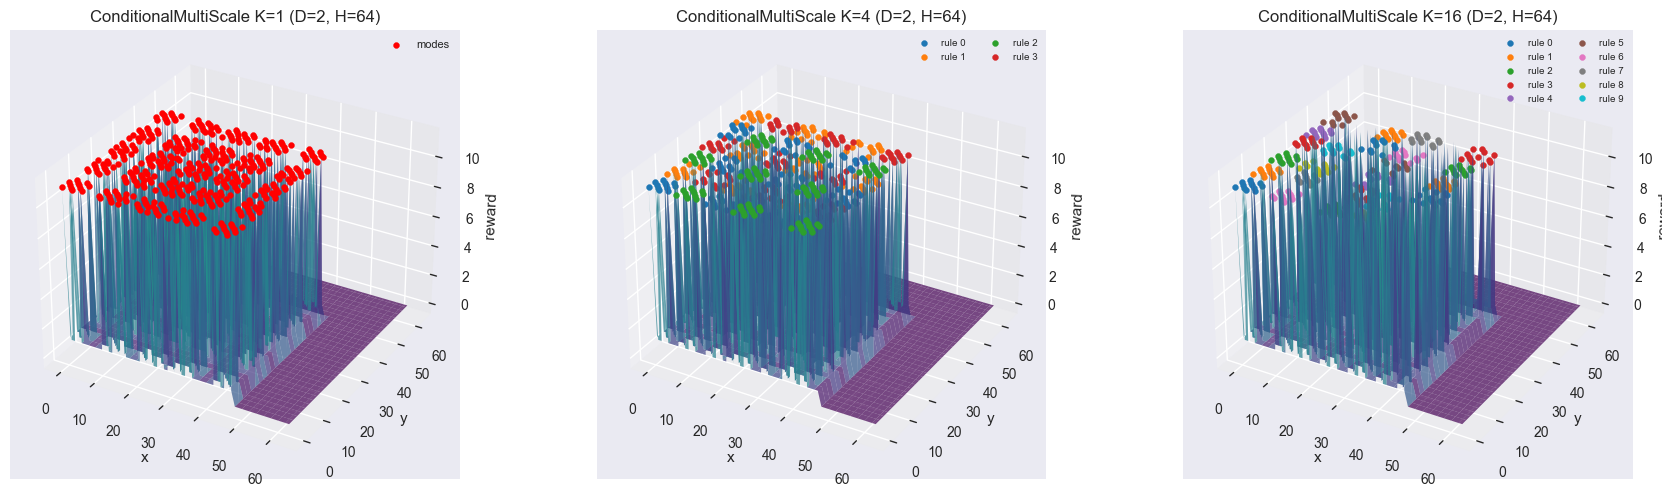

In [13]:
H_K = 64

cms_k_kwargs_base = dict(
    R0=0.1,
    tier_weights=[1.0, 10.0],
    base=8,
    filter_width=6,
    seed=42,
    active_dims=[0, 1],
    cross_dim_mods=[None, 3],
)

fig = plt.figure(figsize=(18, 5))
cms_seeds = [2025, 2026, 2027]
for col, n_rules in enumerate([1, 4, 16]):
    kw = dict(cms_k_kwargs_base, n_rules=n_rules, head_seed=cms_seeds[col])
    env = HyperGrid(
        ndim=2, height=H_K,
        reward_fn_str="conditional_multiscale",
        reward_fn_kwargs=kw, validate_modes=True,
    )
    pts = grid_points_2d_slice(H_K, 2)
    rewards, modes = compute_rewards_and_modes(env, pts)
    rule_idx = _selector_for_state(env, pts) if n_rules > 1 else None
    ax = fig.add_subplot(1, 3, col + 1, projection="3d")
    plot_reward_3d_with_rule_modes(
        ax,
        f"ConditionalMultiScale K={n_rules} (D=2, H={H_K})",
        rewards, modes, rule_idx, n_rules, H_K,
    )
    n_modes = int(modes.sum().item())
    print(
        f"K={n_rules}: {n_modes} modes, density={n_modes / H_K**2:.4f}, "
        f"analytic_total={env.reward_fn.analytic_mode_count():,}"
    )
plt.tight_layout()
plt.show()

## ConditionalMultiScale `filter_shift`: rotating the blind strip

The tier-t filter passes `(digit + sigma_t + filter_shift[t]) mod B < f`.
`sigma_t` is the rule's state-dependent shift (already in the env). Adding a
per-tier *constant* `filter_shift[t]` cyclically rotates the passing window
without changing its size — same density, same per-axis coverage fraction
(`f / B`), but the blind strip lands at a different position on each axis.

At `base=8, f=6`, the passing window covers 6 of 8 digit values (75% of axis).
The default `filter_shift=[0, 0]` puts the blind strip in the upper-right
25% (`top_digit ∈ {6, 7}` → state range `[48, 64)` excluded). With other
`filter_shift[0]` values we can move that strip:

filter_shift[0]=0: passing top_digits=[0, 1, 2, 3, 4, 5], blind=[6, 7] → state range [48, 64) excluded
filter_shift[0]=2: passing top_digits=[0, 1, 2, 3, 6, 7], blind=[4, 5] → state range [32, 48) excluded
filter_shift[0]=4: passing top_digits=[0, 1, 4, 5, 6, 7], blind=[2, 3] → state range [16, 32) excluded


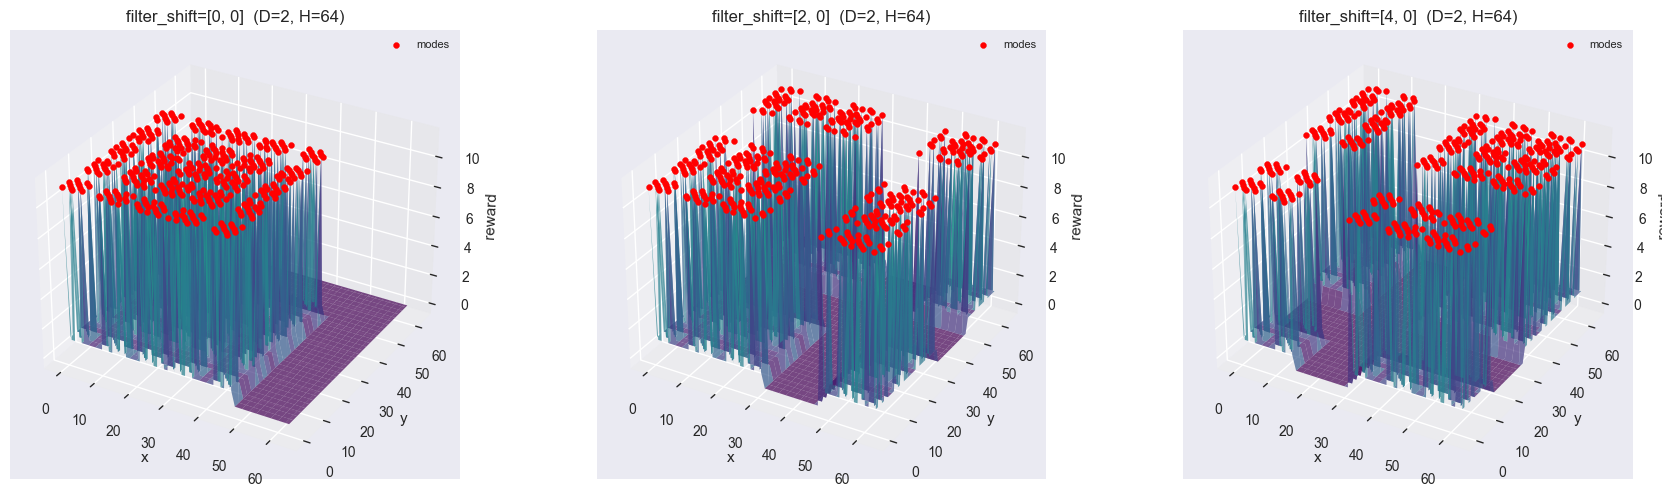

In [14]:
H_K = 64

cms_shift_kwargs = dict(
    R0=0.1,
    tier_weights=[1.0, 10.0],
    base=8,
    filter_width=6,
    seed=42,
    head_seed=2025,
    active_dims=[0, 1],
    cross_dim_mods=[None, 3],
    n_rules=1,
)

fig = plt.figure(figsize=(18, 5))
for col, fs0 in enumerate([0, 2, 4]):
    kw = dict(cms_shift_kwargs, filter_shift=[fs0, 0])
    env = HyperGrid(
        ndim=2, height=H_K,
        reward_fn_str="conditional_multiscale",
        reward_fn_kwargs=kw, validate_modes=True,
    )
    pts = grid_points_2d_slice(H_K, 2)
    rewards, modes = compute_rewards_and_modes(env, pts)
    ax = fig.add_subplot(1, 3, col + 1, projection="3d")
    plot_reward_3d_with_rule_modes(
        ax,
        f"filter_shift=[{fs0}, 0]  (D=2, H={H_K})",
        rewards, modes, rule_idx=None, n_rules=1, H=H_K,
    )
    # Compute which top_digit values pass the tier-0 filter and report the
    # blind strip location for the title context.
    base = kw["base"]
    f = kw["filter_width"]
    passing = sorted([d for d in range(base) if (d + fs0) % base < f])
    blind = sorted(set(range(base)) - set(passing))
    blind_state_lo = blind[0] * (base ** (env.reward_fn.num_levels - 1))
    blind_state_hi = (blind[-1] + 1) * (base ** (env.reward_fn.num_levels - 1))
    print(
        f"filter_shift[0]={fs0}: passing top_digits={passing}, "
        f"blind={blind} → state range [{blind_state_lo}, {blind_state_hi}) excluded"
    )
plt.tight_layout()
plt.show()

## Bitwise/XOR K-rule (K=1 / K=4 / K=16)

We bump H from 16 to **32** so each constrained dim has B=5 bits, giving
M·B=10 bit budget. The default even-parity trunk applied at every bit-plane
would couple x and y rigidly (`x[bit] = y[bit]` for every bit ⇒ `x = y`), so
modes would all sit on the diagonal regardless of K. Instead we use two
trunk tiers with **non-symmetric parity matrices**: tier 0 constrains x's
bit 0 only, tier 1 constrains y's bit 1 only — independent constraints on
each dim. Modes then scatter across the 2D grid, and the K-rule selector's
partition becomes visually obvious.

K=1: 128 modes, density=0.1250, analytic_total=128
K=4: 128 modes, density=0.1250, analytic_total=128
K=16: 128 modes, density=0.1250, analytic_total=128


/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_19101/3228129265.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab = cm.get_cmap("tab10")


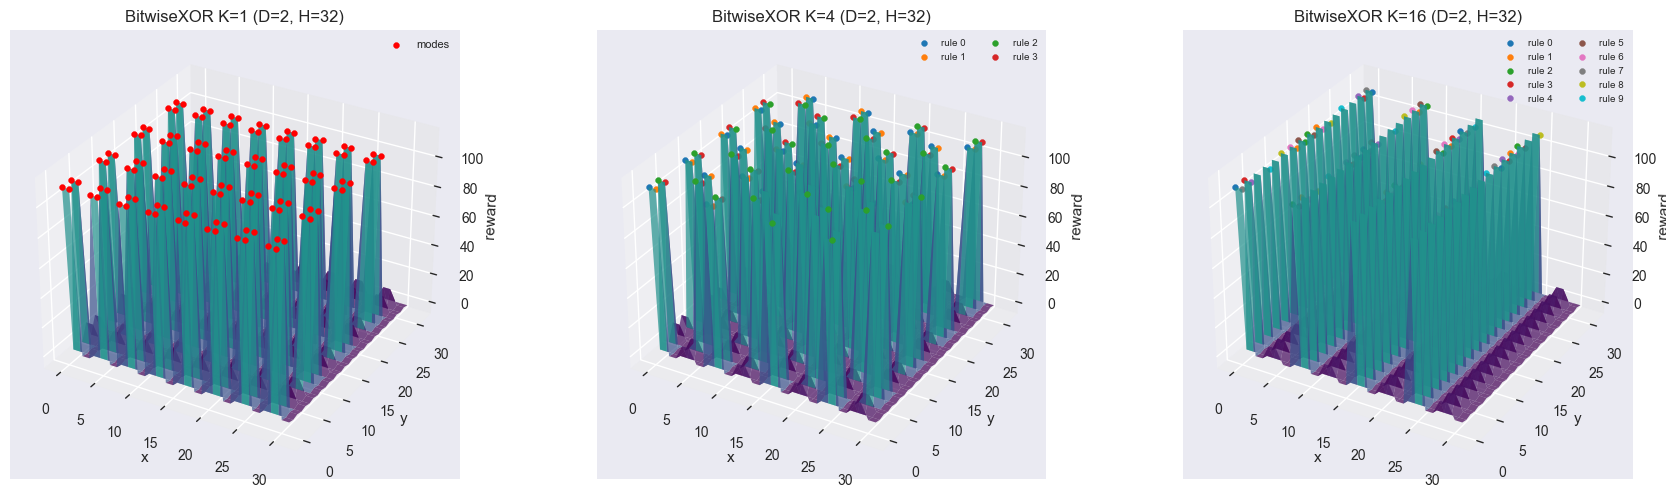

In [15]:
H_K = 32

xor_k_kwargs_base = dict(
    R0=0.1,
    tier_weights=[1.0, 10.0],
    dims_constrained=[0, 1],
    bits_per_tier=[(0, 0), (1, 1)],
    parity_checks=[
        # Tier 0: x[0] = 0 (constrains only x's LSB).
        {"A": torch.tensor([[1, 0]], dtype=torch.long),
         "c": torch.tensor([0], dtype=torch.long)},
        # Tier 1: y[1] = 0 (constrains only y's bit 1).
        {"A": torch.tensor([[0, 1]], dtype=torch.long),
         "c": torch.tensor([0], dtype=torch.long)},
    ],
    head_check_count=1,
    head_weight=100.0,
    head_bit_range=(2, 2),  # head at bit 2, separate from trunk's bits 0/1
)

fig = plt.figure(figsize=(18, 5))
# head_seeds chosen so all three K values produce density-invariant 128 modes
# with ~50% pairwise overlap (visibly distinct partitions). Random head_seeds
# can hit rank-deficient configurations (head_A row in span of trunk + selector)
# that double the K=16 mode count.
xor_seeds = [2025, 2026, 2027]
for col, n_rules in enumerate([1, 4, 16]):
    kw = dict(xor_k_kwargs_base, n_rules=n_rules, head_seed=xor_seeds[col])
    env = HyperGrid(
        ndim=2, height=H_K,
        reward_fn_str="bitwise_xor",
        reward_fn_kwargs=kw, validate_modes=True,
    )
    pts = grid_points_2d_slice(H_K, 2)
    rewards, modes = compute_rewards_and_modes(env, pts)
    rule_idx = _selector_for_state(env, pts) if n_rules > 1 else None
    ax = fig.add_subplot(1, 3, col + 1, projection="3d")
    plot_reward_3d_with_rule_modes(
        ax,
        f"BitwiseXOR K={n_rules} (D=2, H={H_K})",
        rewards, modes, rule_idx, n_rules, H_K,
    )
    n_modes = int(modes.sum().item())
    print(
        f"K={n_rules}: {n_modes} modes, density={n_modes / H_K**2:.4f}, "
        f"analytic_total={env.reward_fn.analytic_mode_count():,}"
    )
plt.tight_layout()
plt.show()

## Multiplicative/Coprime K-rule (K=1 / K=4 / K=16)

H=64 with primes **{2, 3, 5, 7}** (cap=2) gives a smooth-number set of 36
values per dim (vs 17 with just {2,3}) — modes spread throughout the grid
rather than clumping at small coordinates.

At D=2 with `rule_targets` explicitly set to `None` for every rule, the
K-rule head adds no LCM constraint. The K-rule structure here reduces to a
**selector-only relabeling**: all K values share the same trunk-passing
mode set, but the rule colors partition it differently. The fully-active
K-rule head (production K16 preset, ndim=6) requires more dims than D=2
allows: each rule's LCM target needs one prime power per active dim, so
4-prime LCMs need ≥ 4 dims to be reachable.

K=1: 251 modes, density=0.0613, rule_targets=[None]
K=4: 251 modes, density=0.0613, rule_targets=[None, None, None, None]
K=16: 251 modes, density=0.0613, rule_targets=[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_19101/3228129265.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab = cm.get_cmap("tab10")


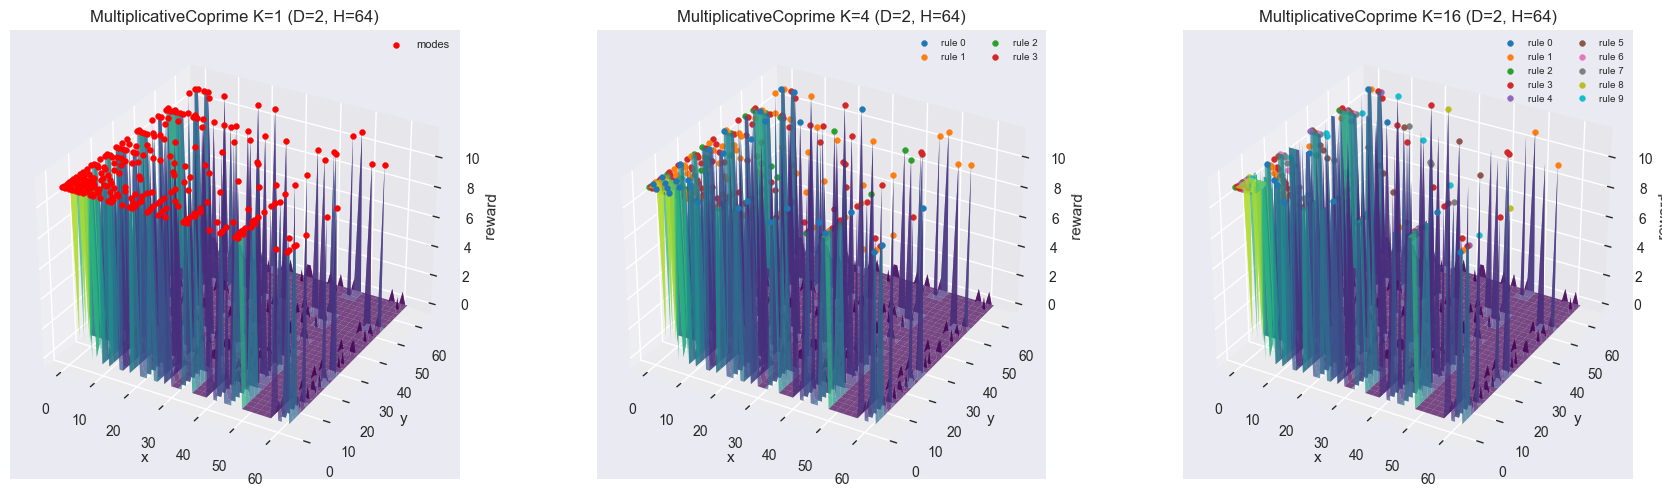

In [16]:
H_K = 64

mc_k_kwargs_base = dict(
    R0=0.1,
    tier_weights=[1.0, 10.0],
    primes=[2, 3, 5, 7],
    exponent_caps=[2, 2],
    active_dims=[0, 1],
    coprime_pairs=[(0, 1)],
    coprime_start_tier=1,
    target_lcms=[None, None],
)

fig = plt.figure(figsize=(18, 5))
mc_seeds = [2025, 2026, 2027]
for col, n_rules in enumerate([1, 4, 16]):
    kw = dict(
        mc_k_kwargs_base,
        n_rules=n_rules,
        head_seed=mc_seeds[col],
        rule_targets=[None] * n_rules,  # head trivially passes — selector-only
    )
    env = HyperGrid(
        ndim=2, height=H_K,
        reward_fn_str="multiplicative_coprime",
        reward_fn_kwargs=kw, validate_modes=True,
    )
    pts = grid_points_2d_slice(H_K, 2)
    rewards, modes = compute_rewards_and_modes(env, pts)
    rule_idx = _selector_for_state(env, pts) if n_rules > 1 else None
    ax = fig.add_subplot(1, 3, col + 1, projection="3d")
    plot_reward_3d_with_rule_modes(
        ax,
        f"MultiplicativeCoprime K={n_rules} (D=2, H={H_K})",
        rewards, modes, rule_idx, n_rules, H_K,
    )
    n_modes = int(modes.sum().item())
    print(
        f"K={n_rules}: {n_modes} modes, density={n_modes / H_K**2:.4f}, "
        f"rule_targets={env.reward_fn.rule_targets}"
    )
plt.tight_layout()
plt.show()

## Density invariance under K

A direct verification of the K-rule contract: total mode count is invariant
in `n_rules`. Each panel re-uses the kwargs from the K-rule visualizations
above (D=2 slice, full enumeration over H^2 states) and shows the total
mode count per K. Bars within each panel should be flat: the K-rule
selector partitions the canonical mode set rather than multiplying it.

The `head_seed` differs across K values (matching the visualizations above),
so the *positions* of modes shift between panels, but the *count* stays
fixed by construction.


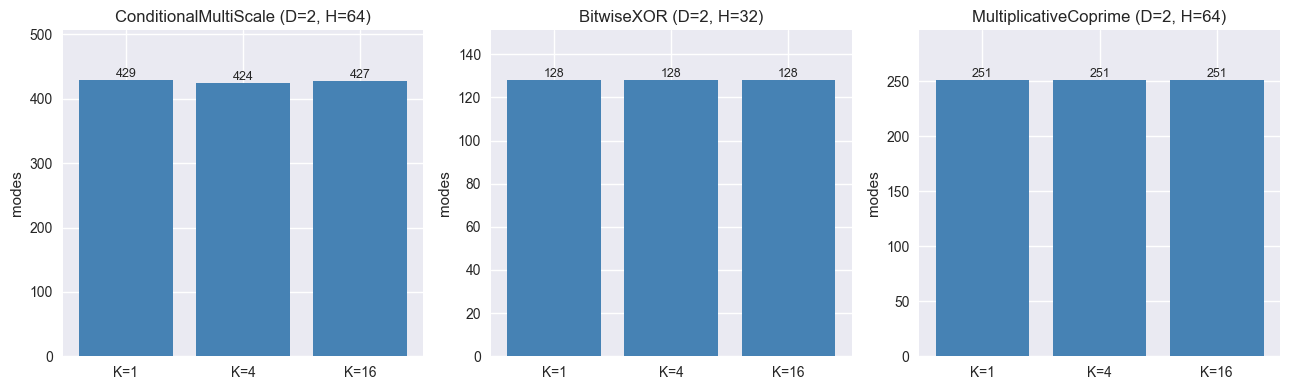

In [17]:
# Density invariance under K — re-uses kwargs from cells 24/28/30 (the K-rule
# visualization cells) and enumerates the full D=2 state space to count modes
# per K. Same kwargs, same K sweep, just aggregated as a bar chart.

K_values = [1, 4, 16]


def _count_modes_D2(env, H):
    pts = grid_points_2d_slice(H, 2)
    _, modes = compute_rewards_and_modes(env, pts)
    return int(modes.sum().item())


# ConditionalMultiScale (matches cell 24)
H_cms = 64
cms_base = dict(
    R0=0.1, tier_weights=[1.0, 10.0], base=8, filter_width=6,
    seed=42, active_dims=[0, 1], cross_dim_mods=[None, 3],
)
cms_seeds = [2025, 2026, 2027]
cms_counts = [
    _count_modes_D2(
        HyperGrid(
            ndim=2, height=H_cms, reward_fn_str="conditional_multiscale",
            reward_fn_kwargs=dict(cms_base, n_rules=K, head_seed=s),
            validate_modes=False,
        ),
        H_cms,
    )
    for K, s in zip(K_values, cms_seeds)
]

# BitwiseXOR (matches cell 28)
H_xor = 32
xor_base = dict(
    R0=0.1, tier_weights=[1.0, 10.0],
    dims_constrained=[0, 1], bits_per_tier=[(0, 0), (1, 1)],
    parity_checks=[
        {"A": torch.tensor([[1, 0]], dtype=torch.long),
         "c": torch.tensor([0], dtype=torch.long)},
        {"A": torch.tensor([[0, 1]], dtype=torch.long),
         "c": torch.tensor([0], dtype=torch.long)},
    ],
    head_check_count=1, head_weight=100.0, head_bit_range=(2, 2),
)
xor_seeds = [2025, 2026, 2027]
xor_counts = [
    _count_modes_D2(
        HyperGrid(
            ndim=2, height=H_xor, reward_fn_str="bitwise_xor",
            reward_fn_kwargs=dict(xor_base, n_rules=K, head_seed=s),
            validate_modes=False,
        ),
        H_xor,
    )
    for K, s in zip(K_values, xor_seeds)
]

# MultiplicativeCoprime (matches cell 30; selector-only K-rule)
H_mc = 64
mc_base = dict(
    R0=0.1, tier_weights=[1.0, 10.0],
    primes=[2, 3, 5, 7], exponent_caps=[2, 2],
    active_dims=[0, 1], coprime_pairs=[(0, 1)],
    coprime_start_tier=1, target_lcms=[None, None],
)
mc_seeds = [2025, 2026, 2027]
mc_counts = [
    _count_modes_D2(
        HyperGrid(
            ndim=2, height=H_mc, reward_fn_str="multiplicative_coprime",
            reward_fn_kwargs=dict(
                mc_base, n_rules=K, head_seed=s,
                rule_targets=[None] * K,
            ),
            validate_modes=False,
        ),
        H_mc,
    )
    for K, s in zip(K_values, mc_seeds)
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
panels = [
    ("ConditionalMultiScale", cms_counts, H_cms),
    ("BitwiseXOR", xor_counts, H_xor),
    ("MultiplicativeCoprime", mc_counts, H_mc),
]
for ax, (label, counts, H) in zip(axes, panels):
    bars = ax.bar([f"K={K}" for K in K_values], counts, color="steelblue")
    ax.set_title(f"{label} (D=2, H={H})")
    ax.set_ylabel("modes")
    ax.set_ylim(0, max(counts) * 1.18)
    for bar, n in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, n,
            f"{n:,}", ha="center", va="bottom", fontsize=9,
        )
plt.tight_layout()
plt.show()


# Random and Corrupted Rewards

The structured compositional rewards above (Bitwise/XOR, Multiplicative/Coprime, Conditional Multi-Scale) all have
exploitable algebraic or hierarchical structure. The two rewards below sit at the **opposite end of the spectrum**:
they test GFlowNet behaviour when mode structure is **fully random** or a **mixture of structured and random**.

This lets us benchmark which approaches work best when:
- Mode placement is truly unpredictable (Uniform Random)
- Structure is partially degraded by noise at every tier level (Corrupted)

## Uniform Random Reward

Each state is independently a mode with probability `mode_prob`, assigned via a
deterministic hash on state coordinates. There is **zero exploitable spatial or algebraic structure** --
modes are scattered uniformly at random across the grid.

$$R(s) = R_0 + R_{\text{mode}} \cdot \mathbf{1}[\text{hash}(s) < p]$$

The binary reward landscape should look like random salt-and-pepper noise.

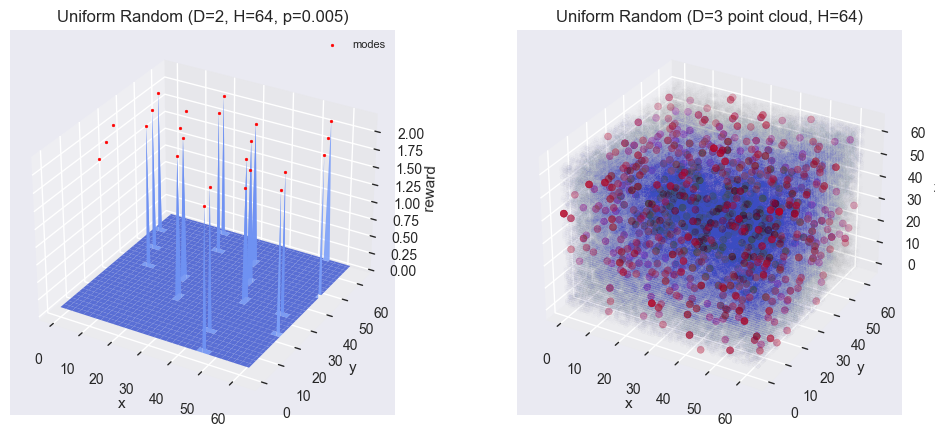

D=2: n_modes (distinct): None
D=2: % of plotted grid states that are modes: 0.5859%
D=3 (point cloud): n_modes (distinct): None
D=3 (point cloud): % of plotted grid states that are modes: 0.4870%


In [18]:
# Uniform Random: each state is independently a mode with probability mode_prob
ur_kwargs = dict(R0=0.1, R_mode=2.0, mode_prob=0.005, seed=42)

# D=2
ur_env2 = build_env("uniform_random", ur_kwargs, validate_modes=True, ndim=2)
pts2 = grid_points_2d_slice(H, 2)
ur_rewards2, ur_modes2 = compute_rewards_and_modes(ur_env2, pts2)

# D=3 point cloud
ur_env3 = build_env("uniform_random", ur_kwargs, validate_modes=True, ndim=3)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_reward_3d(
    ax1,
    "Uniform Random (D=2, H={}, p={})".format(H, ur_kwargs["mode_prob"]),
    ur_rewards2,
    ur_modes2,
    vmin=0,
    cmap_name="coolwarm",
    H=H,
)
ax2 = fig.add_subplot(122, projection="3d")
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards3_pc, _ = compute_rewards_and_modes(ur_env3, pts3_pc)
plot_pointcloud_3d(
    ax2,
    "Uniform Random (D=3 point cloud, H={})".format(H),
    pts3_pc,
    rewards3_pc,
    cmap_name="coolwarm",
)
plt.show()

summarize_modes(ur_env2, ur_modes2, label="D=2")
mask3_pc = ur_env3.mode_mask(ur_env3.States(pts3_pc))
summarize_modes(ur_env3, mask3_pc, label="D=3 (point cloud)")

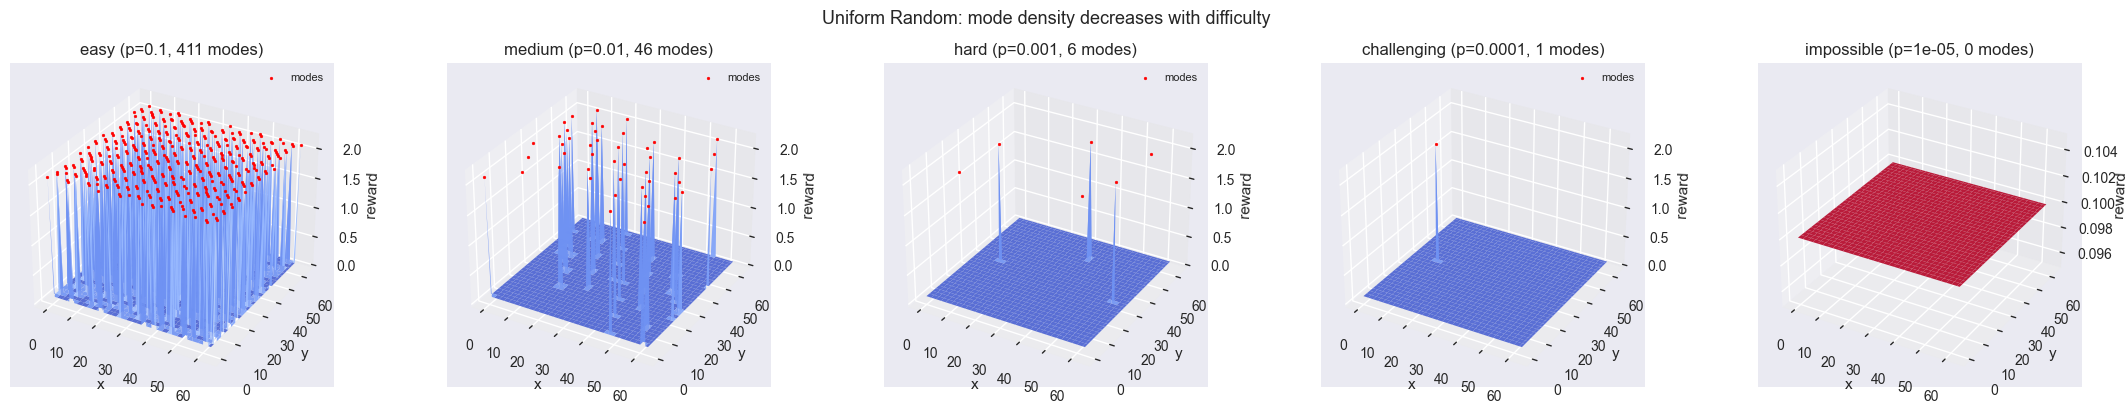

In [19]:
# Uniform Random: mode density comparison across presets
fig, axes = plt.subplots(1, 5, figsize=(22, 4), subplot_kw={"projection": "3d"})
pts2 = grid_points_2d_slice(H, 2)

for ax, (name, preset) in zip(axes, get_reward_presets("uniform_random", D, H).items()):
    env = build_env("uniform_random", preset, validate_modes=(preset["mode_prob"] >= 0.001), ndim=2)
    rewards, modes = compute_rewards_and_modes(env, pts2)
    n_modes = int(modes.sum().item())
    plot_reward_3d(
        ax,
        f"{name} (p={preset['mode_prob']}, {n_modes} modes)",
        rewards,
        modes,
        vmin=0,
        cmap_name="coolwarm",
        H=H,
    )

plt.suptitle("Uniform Random: mode density decreases with difficulty", fontsize=13)
plt.tight_layout()
plt.show()

## Corrupted Reward

Wraps a structured tiered reward and applies **per-tier corruption**: at each tier, a fraction
`corruption_rate` of states that earned that tier's bonus have it "moved" to a random location.
This degrades the compositional structure at **every level** proportionally.

For tier $t$ with indicator $\text{pass}_t(s)$:
- **Demote**: if $\text{pass}_t(s)$ and $\text{hash}(s) < c$, remove tier $t$'s contribution
- **Promote**: if $\neg\text{pass}_t(s)$ and $\text{hash}(s) < r_t$, add tier $t$'s contribution

where $r_t$ is calibrated so that E[promotions] $\approx$ E[demotions], preserving the overall
mode count while scrambling the structure.

Below we show the same Conditional Multi-Scale base reward with increasing corruption.

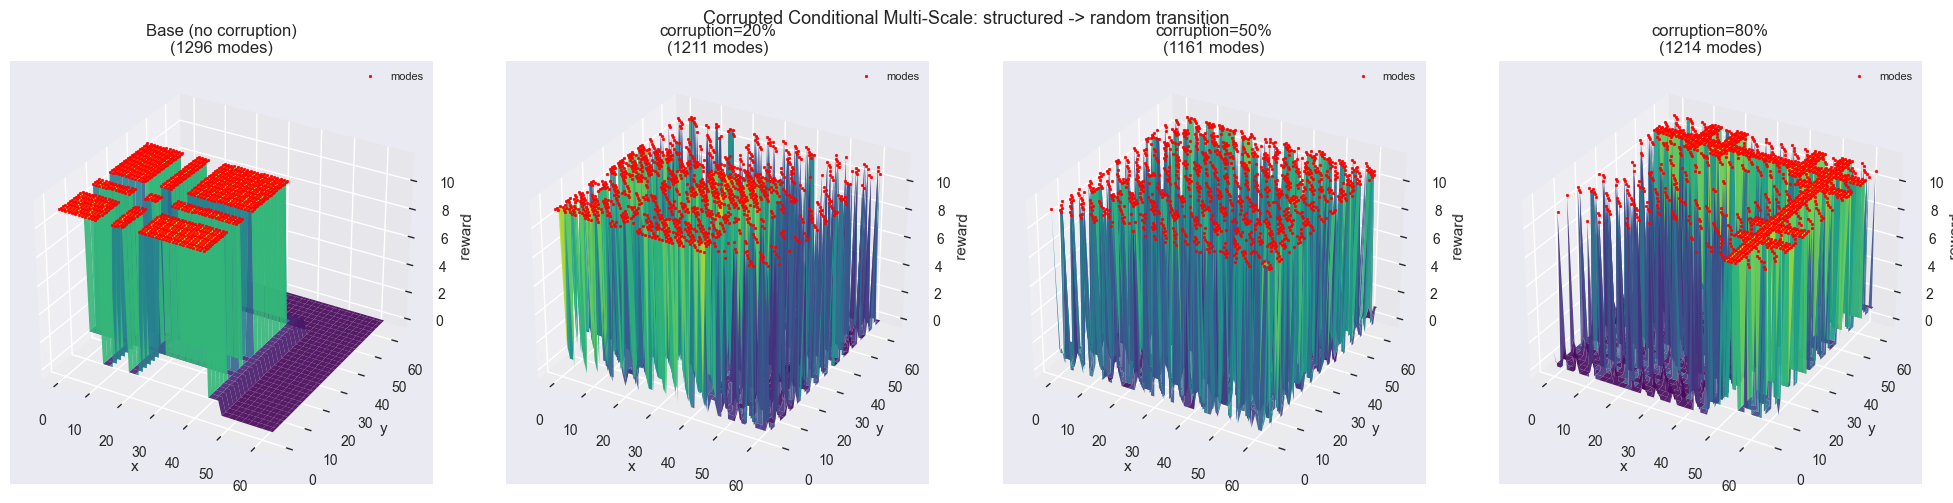

In [20]:
# Corrupted: progressive corruption of a Conditional Multi-Scale base
# Use the same CMS kwargs as the earlier section for direct comparison
cms_base_kwargs = dict(
    R0=0.1,
    tier_weights=[1.0, 10.0],
    base=4,
    filter_width=3,
    seed=42,
    active_dims=[0, 1],
)

corruption_rates = [0.0, 0.2, 0.5, 0.8]
fig, axes = plt.subplots(1, len(corruption_rates), figsize=(20, 5), subplot_kw={"projection": "3d"})
pts2 = grid_points_2d_slice(H, 2)

for ax, cr in zip(axes, corruption_rates):
    if cr == 0.0:
        # Show uncorrupted base for comparison
        env = build_env("conditional_multiscale", cms_base_kwargs, validate_modes=True, ndim=2)
        label = "Base (no corruption)"
    else:
        corr_kwargs = dict(
            base_reward="conditional_multiscale",
            base_kwargs=cms_base_kwargs,
            corruption_rate=cr,
            seed=137,
        )
        env = build_env("corrupted", corr_kwargs, validate_modes=True, ndim=2)
        label = f"corruption={cr:.0%}"

    rewards, modes = compute_rewards_and_modes(env, pts2)
    n_modes = int(modes.sum().item())
    plot_reward_3d(
        ax,
        f"{label}\n({n_modes} modes)",
        rewards,
        modes,
        vmin=0,
        cmap_name="viridis",
        H=H,
    )

plt.suptitle("Corrupted Conditional Multi-Scale: structured -> random transition", fontsize=13)
plt.tight_layout()
plt.show()

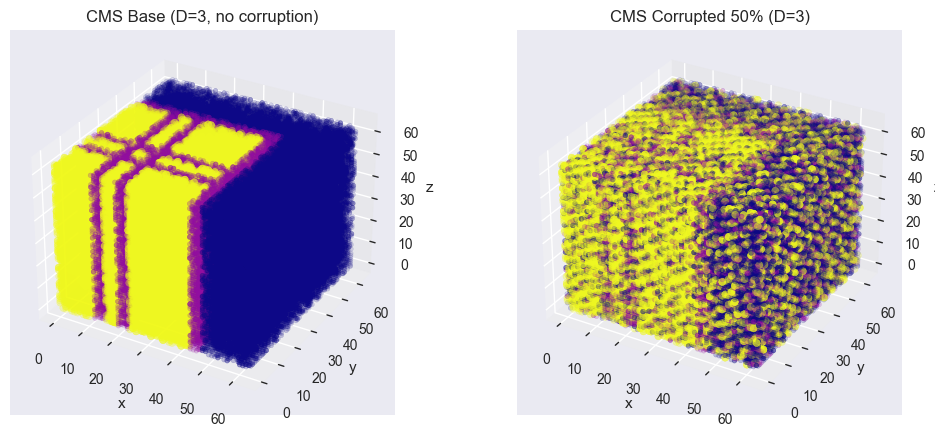

CMS base D=3: n_modes (distinct): None
CMS base D=3: % of plotted grid states that are modes: 31.6430%
CMS corrupted 50% D=3: n_modes (distinct): None
CMS corrupted 50% D=3: % of plotted grid states that are modes: 31.0815%


In [21]:
# Corrupted: D=3 point cloud -- structured vs heavily corrupted
fig = plt.figure(figsize=(12, 5))

# Left: uncorrupted base
cms_env3 = build_env("conditional_multiscale", cms_base_kwargs, validate_modes=False, ndim=3)
pts3_pc = sample_points_nd(H, 3, num_samples=200000)
rewards_base, _ = compute_rewards_and_modes(cms_env3, pts3_pc)

ax1 = fig.add_subplot(121, projection="3d")
plot_pointcloud_3d(
    ax1,
    "CMS Base (D=3, no corruption)",
    pts3_pc,
    rewards_base,
    cmap_name="plasma",
    min_nonzero_alpha=0.3,
)

# Right: 30% corrupted
corr_kwargs_3d = dict(
    base_reward="conditional_multiscale",
    base_kwargs=cms_base_kwargs,
    corruption_rate=0.3,
    seed=137,
)
corr_env3 = build_env("corrupted", corr_kwargs_3d, validate_modes=False, ndim=3)
rewards_corr, _ = compute_rewards_and_modes(corr_env3, pts3_pc)

ax2 = fig.add_subplot(122, projection="3d")
plot_pointcloud_3d(
    ax2,
    "CMS Corrupted 50% (D=3)",
    pts3_pc,
    rewards_corr,
    cmap_name="plasma",
    min_nonzero_alpha=0.3,
)

plt.show()

# Mode summaries
mask_base = cms_env3.mode_mask(cms_env3.States(pts3_pc))
mask_corr = corr_env3.mode_mask(corr_env3.States(pts3_pc))
summarize_modes(cms_env3, mask_base, label="CMS base D=3")
summarize_modes(corr_env3, mask_corr, label="CMS corrupted 50% D=3")

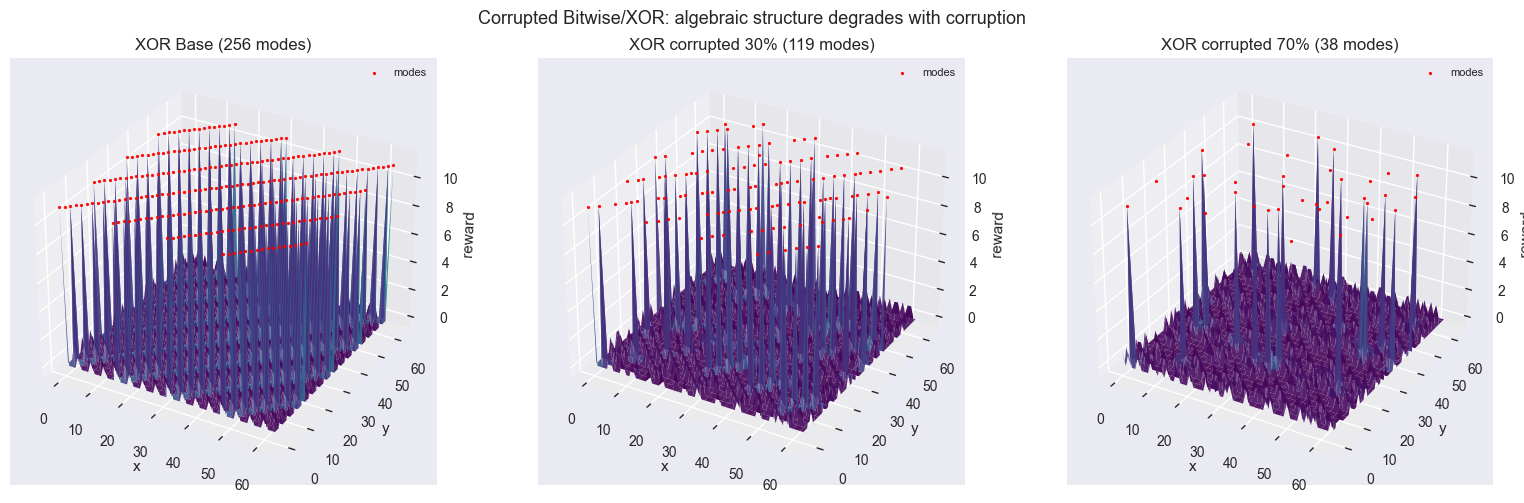

In [22]:
# Corrupted with a Bitwise/XOR base instead of CMS
xor_base_kwargs = get_reward_presets("bitwise_xor", D, H)["easy"].copy()
xor_base_kwargs.update(dict(
    dims_constrained=[0, 1],
    bits_per_tier=[(0, 1), (0, 3)],
    tier_weights=[1.0, 10.0],
))
xor_base_kwargs.pop("parity_checks", None)

corruption_rates = [0.0, 0.3, 0.7]
fig, axes = plt.subplots(1, len(corruption_rates), figsize=(16, 5), subplot_kw={"projection": "3d"})
pts2 = grid_points_2d_slice(H, 2)

for ax, cr in zip(axes, corruption_rates):
    if cr == 0.0:
        env = build_env("bitwise_xor", xor_base_kwargs, validate_modes=True, ndim=2)
        label = "XOR Base"
    else:
        corr_kwargs = dict(
            base_reward="bitwise_xor",
            base_kwargs=xor_base_kwargs,
            corruption_rate=cr,
            seed=137,
        )
        env = build_env("corrupted", corr_kwargs, validate_modes=True, ndim=2)
        label = f"XOR corrupted {cr:.0%}"

    rewards, modes = compute_rewards_and_modes(env, pts2)
    n_modes = int(modes.sum().item())
    plot_reward_3d(
        ax,
        f"{label} ({n_modes} modes)",
        rewards,
        modes,
        vmin=0,
        cmap_name="viridis",
        H=H,
    )

plt.suptitle("Corrupted Bitwise/XOR: algebraic structure degrades with corruption", fontsize=13)
plt.tight_layout()
plt.show()